# Asmit EDA

In [349]:
%%capture
!pip install -r requirements.txt

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import re

## Data Integrity

Load data

In [351]:
sopp = pd.read_csv('./data/sopp_svi_merged.csv')
df = sopp.copy()
df.columns

Index(['Unnamed: 0', 'raw_row_number', 'date', 'time', 'service_area',
       'subject_age', 'subject_race', 'subject_sex', 'type', 'arrest_made',
       'citation_issued', 'warning_issued', 'outcome', 'contraband_found',
       'search_conducted', 'search_person', 'search_vehicle', 'search_basis',
       'reason_for_search', 'reason_for_stop', 'raw_action_taken',
       'raw_subject_race_description', 'serv', 'svi_rpl_themes'],
      dtype='str')

Basic data checks. Much of the missing data is in post-outcome features, which are not valid predictors of a search in any case because that information is not available before a stop is conducted.

In [2]:
print("=== BASIC OVERVIEW ===")
print("Shape:", df.shape)
print("Columns:", len(df.columns))

# Duplicates
print("\n=== DUPLICATES ===")
print("Exact duplicate rows:", int(df.duplicated().sum()))
for idcol in ["raw_row_number", "stop_id", "id"]:
    if idcol in df.columns:
        print(f"Duplicate values in {idcol}:", int(df[idcol].duplicated().sum()))

# Missingness
print("\n=== MISSINGNESS (TOP 5) ===")
miss = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True)
}).sort_values(["pct_missing", "n_unique"], ascending=[False, False])

print(miss.head())

=== BASIC OVERVIEW ===


NameError: name 'df' is not defined

Check that categorical data is clean

In [353]:
# Categorical data
print("\n=== CATEGORICAL DATA CHECKS ===")

def cat_flags(s: pd.Series):
    """
    Checks if categorical column has has
    leading symbols or unnecessary whitespaces.
    """
    s = s.dropna().astype(str)
    if len(s) == 0:
        return dict(n_unique=0, pct_ws_edges=0.0, pct_leading_symbols=0.0, pct_double_spaces=0.0)

    return dict(
        n_unique=int(s.nunique()),
        pct_ws_edges=float((s.str.match(r"^\s+|\s+$").mean() * 100)),
        pct_leading_symbols=float((s.str.match(r"^[^\w]+").mean() * 100)),
        pct_double_spaces=float((s.str.contains(r"\s{2,}").mean() * 100)),
    )

cat_cols = [c for c in df.columns if df[c].dtype == "object"]
cat_rep = []
for c in cat_cols:
    rep = cat_flags(df[c])
    rep["col"] = c
    cat_rep.append(rep)

cat_rep = pd.DataFrame(cat_rep).sort_values(
    ["pct_leading_symbols", "pct_ws_edges", "pct_double_spaces", "n_unique"],
    ascending=False
)

print(cat_rep.head())


=== CATEGORICAL DATA CHECKS ===
   n_unique  pct_ws_edges  pct_leading_symbols  pct_double_spaces  \
0         2           0.0                  0.0                0.0   
1         2           0.0                  0.0                0.0   
2         2           0.0                  0.0                0.0   
3         2           0.0                  0.0                0.0   
4         2           0.0                  0.0                0.0   

                col  
0       arrest_made  
1   citation_issued  
2    warning_issued  
3  contraband_found  
4     search_person  


Missing data checks on numeric data

In [354]:
# Numeric data
print("\n=== NUMERIC DATA CHECKS===")
num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and df[c].dtype != bool]
num_rep = []
for c in num_cols:
    x = df[c]
    num_rep.append({
        "col": c,
        "pct_missing": float(x.isna().mean() * 100),
        "min": float(np.nanmin(x)) if x.notna().any() else np.nan,
        "p1": float(np.nanpercentile(x.dropna(), 1)) if x.notna().any() else np.nan,
        "median": float(np.nanmedian(x)) if x.notna().any() else np.nan,
        "p99": float(np.nanpercentile(x.dropna(), 99)) if x.notna().any() else np.nan,
        "max": float(np.nanmax(x)) if x.notna().any() else np.nan,
        "n_unique": int(x.nunique(dropna=True))
    })

num_rep = pd.DataFrame(num_rep).sort_values(["pct_missing", "n_unique"], ascending=[False, False])
print("Shape of numeric subset:", num_rep.shape)
print(num_rep.head())


=== NUMERIC DATA CHECKS===
Shape of numeric subset: (4, 8)
              col  pct_missing         min           p1         median  \
1     subject_age     3.123279   10.000000    18.000000      34.000000   
2            serv     3.035556  110.000000   110.000000     510.000000   
3  svi_rpl_themes     3.035556    0.075382     0.075382       0.241848   
0      Unnamed: 0     0.000000    0.000000  3830.260000  191513.000000   

             p99            max  n_unique  
1      75.000000     100.000000        91  
2     930.000000     930.000000        19  
3       0.849382       0.849382        19  
0  379195.740000  383026.000000    383027  


Date/time parsing and some feature engineering

In [355]:
# Parse date
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date"].dt.year.astype("Int64")
df["month"] = df["date"].dt.month.astype("Int64")

# Day of week
df["day_of_week"] = df["date"].dt.day_name()

# Parse time
t1 = pd.to_datetime(df["time"], format="%H:%M:%S", errors="coerce")
t2 = pd.to_datetime(df["time"], format="%H:%M", errors="coerce")
time_parsed = t1.fillna(t2)

df["hour"] = time_parsed.dt.hour

# is_night: keep missing if hour missing
df["is_night"] = np.where(df["hour"].isna(), np.nan, (df["hour"] >= 18) | (df["hour"] < 6))
df["is_night"] = df["is_night"].astype("boolean")

Basic checks on the outcome `search_conducted`

In [357]:
print("Search conducted column checks")
print("dtype:", df["search_conducted"].dtype)
print("missing:", df["search_conducted"].isna().sum())

# Overall search rate
counts = df["search_conducted"].value_counts(dropna=False)
print("\nCounts:")
print(counts)

search_rate = df["search_conducted"].astype(int).mean()
print("Search percent:", round(100 * search_rate, 3), "%")

# Search rate + SVI by service area
tmp = pd.DataFrame({"service_area": df["service_area"].astype(str), "searched": df["search_conducted"], "svi": df["svi_rpl_themes"]})
print("\nSearch rate by service_area (top 10 highest, min n=200):")
grp = tmp.groupby("service_area").agg(rate=("searched", "mean"), svi=("svi", "mean"), n=("searched", "size"))
grp = grp[grp["n"] >= 200].sort_values("rate", ascending=False)
print(grp.head(10))

Search conducted column checks
dtype: bool
missing: 0

Counts:
search_conducted
False    366739
True      16288
Name: count, dtype: int64
Search percent: 4.252 %

Search rate by service_area (top 10 highest, min n=200):
                  rate       svi      n
service_area                           
830           0.111170  0.757934  13295
440           0.107294  0.849382  13710
510           0.095388  0.549244  14897
820           0.090968  0.496553  12268
430           0.089688  0.653392  15632
810           0.054347  0.234884  13929
720           0.042398  0.683421  17430
620           0.041382  0.347316  20951
530           0.040062  0.321448    649
610           0.034949  0.121181  18999


Logical checks on `search_conducted` with related columns. We will drop these later, but they are useful to check that the column is labeled consistently.

In [304]:
# 1) Check that search_person/vehicle aligns with search_conducted
bad1 = df[(df["search_conducted"] == False) & ((df["search_person"] == True) | (df["search_vehicle"] == True))]
print("Check 1: searched person/vehicle but search_conducted==False")
print("Count:", len(bad1))
if len(bad1) > 0:
    print(bad1[["search_conducted","search_person","search_vehicle"]].head())

# 2) For searched stops, either search_person or search_vehicle
# should be True, if recorded
bad2 = df[(df["search_conducted"] == True) & (df["search_person"] == False) & (df["search_vehicle"] == False)]
print("Check 2: search_conducted==True but both search_person and search_vehicle are False")
print("Count:", len(bad2))
if len(bad2) > 0:
    print(bad2[["search_conducted","search_person","search_vehicle"]].head())

# 2.1) Extends 2) by checking when search_person/search_vehicle is missing
# for records in which a search was conducted
searched = df[df["search_conducted"] == True]
print("  Check 2.1: Among searched stops:")
print("  search_person missing %:", round(100 * searched["search_person"].isna().mean(), 2))
print("  search_vehicle missing %:", round(100 * searched["search_vehicle"].isna().mean(), 2))

# 2.2) Searched stops where both search_person and search_vehicle are missing
searched_both_missing = df[(df["search_conducted"] == True) & df["search_person"].isna() & df["search_vehicle"].isna()]
print("  Both search_person and search_vehicle missing:", round(100 * len(searched_both_missing) / len(searched), 2))


Check 1: searched person/vehicle but search_conducted==False
Count: 0
Check 2: search_conducted==True but both search_person and search_vehicle are False
Count: 0
  Check 2.1: Among searched stops:
  search_person missing %: 13.45
  search_vehicle missing %: 13.45
  Both search_person and search_vehicle missing: 13.45


## Feature Selection

Begin by removing features that contain post-stop information. These are naturally invalid predictors of search outcomes since they are recorded *after* the search is conducted or not conducted. Also drop unnecessary columns (e.g., `Unnamed: 0`) from the data wrangling step.

In [305]:
print("All Columns before dropping:")
for i, col in enumerate(df.columns.tolist()):
    print(col)

All Columns before dropping:
Unnamed: 0
raw_row_number
date
time
service_area
subject_age
subject_race
subject_sex
type
arrest_made
citation_issued
warning_issued
outcome
contraband_found
search_conducted
search_person
search_vehicle
search_basis
reason_for_search
reason_for_stop
raw_action_taken
raw_subject_race_description
serv
svi_rpl_themes
year
month
day_of_week
hour
is_night


Define columns to drop. We first drop obviously irrelevant columns. Most of these were created during the data wrangling stage. We also drop post-stop columns here 

In [306]:
# Drop post-stop information since it would cause data leakage
drop_post_stop = [
    "contraband_found",     # Recorded after search
    "search_basis",         # Recorded after search
    "reason_for_search",    # Recorded after search
    "search_person",        # Recorded after search
    "search_vehicle",       # Recorded after search
    "outcome",              # Downstream outcome
    "arrest_made",          # Downstream outcome
    "citation_issued",      # Downstream outcome
    "warning_issued",       # Downstream outcome
    "raw_action_taken"      # Downstream outcome
]

drop_irrelevant = [
    "Unnamed: 0",                   # Row id from data wrangling
    "raw_row_number",               # Row id from data wrangling
    "raw_subject_race_description", # Redundant with subject_race
    "date",                         # Redundant with engineered columns
    "time",                         # Redundant with engineered columns
    "serv",                         # Redundant with service_area
    "type",                         # No variance in column. Poor predictor.
]

Now we want to drop columns with a large amount of missing data. We noted earlier that missing data is fortunately not a big issue column-wise in the data set. Hence, we require that columns have at least 95% of their rows filled. From the below chunk, we can see that the only columns dropped are those which we would have dropped earlier anyway.

In [307]:
missing_pct = df.isna().mean().sort_values(ascending=False)
missing_thresh = 0.05 # Threshold (may want to tune)

drop_high_missing = missing_pct[missing_pct >= missing_thresh].index.tolist()
print("Columns with >= {:.0%} missing:".format(missing_thresh))
print(drop_high_missing)

if set(drop_high_missing).issubset(set(drop_post_stop + drop_irrelevant)):
    print("All of the above columns are a subset of the earlier dropped columns.")

Columns with >= 5% missing:
['reason_for_search', 'search_basis', 'contraband_found', 'outcome', 'arrest_made', 'citation_issued', 'raw_action_taken', 'warning_issued']
All of the above columns are a subset of the earlier dropped columns.


Now we will drop those columns.

In [308]:
drop_cols = list(set(drop_high_missing + drop_post_stop + drop_irrelevant))
print("\nDropping {} columns total:".format(len(drop_cols)))
df_dropped = df.drop(columns=drop_cols)

print("\nReduced df shape:", df_dropped.shape)
print("Remaining columns:")
print(df_dropped.columns)
print("\nPreview of the remaining data:")
print(df_dropped.head())


Dropping 17 columns total:

Reduced df shape: (383027, 12)
Remaining columns:
Index(['service_area', 'subject_age', 'subject_race', 'subject_sex',
       'search_conducted', 'reason_for_stop', 'svi_rpl_themes', 'year',
       'month', 'day_of_week', 'hour', 'is_night'],
      dtype='str')

Preview of the remaining data:
  service_area  subject_age            subject_race subject_sex  \
0          110         24.0                   white        male   
1          320         42.0                   white        male   
2          320         29.0  asian/pacific islander        male   
3          610         23.0                   white        male   
4          930         35.0                hispanic        male   

   search_conducted      reason_for_stop  svi_rpl_themes  year  month  \
0             False     Moving Violation        0.241848  2014      1   
1             False     Moving Violation        0.213643  2014      1   
2             False     Moving Violation        0.21364

# Data Pre-processing

In [1]:
df = df_dropped.copy()

# Helper to normalize string labels
def normalize_label(x):
    if pd.isna(x):
        return x
    x = str(x).strip()
    x = re.sub(r"^[^\w]+", "", x)  # remove unnecessary leading characters
    x = re.sub(r"\s+", " ", x)     # remove repeated whitespace
    return x

# Clean/standardize specific fields

# service_area: treat 'Unknown' as missing
if "service_area" in df.columns:
    df["service_area"] = df["service_area"].map(normalize_label)
    df.loc[df["service_area"].astype(str).str.lower().isin(["unknown", "nan", "none", ""]), "service_area"] = pd.NA

# year/month: convert floats to integers first
for c in ["year", "month"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")

print(df.head())

NameError: name 'df_dropped' is not defined

Encoding categorical variables. We will begin with the only two binary fields.

In [ ]:
df["subject_sex"] = df["subject_sex"].map({"male": 1, "female": 0})
df["search_conducted"] = df["search_conducted"].astype(int)

Now, we will convert categorical fields and observe their levels.

In [ ]:
# Define categorical (> 2 levels) predictors
cat_cols = [
    "subject_race",
    "year",
    "month",
    "reason_for_stop",
    "service_area",
    "day_of_week",
]

cat_cols = [c for c in cat_cols if c in df.columns]

# Normalize labels for strings and convert to category
for c in cat_cols:
    if df[c].dtype == "object":
        df[c] = df[c].map(normalize_label)

for c in cat_cols:
    df[c] = df[c].astype("category")

print("Converted to category:", cat_cols)

# Inspect levels + counts
for c in cat_cols:
    print(f"\n=== {c} ===")
    print("dtype:", df[c].dtype)
    print("n_unique:", df[c].nunique(dropna=True))
    print("missing %:", round(df[c].isna().mean() * 100, 3))
    print("Top levels:")
    print(df[c].value_counts(dropna=False).head(15))

Converted to category: ['subject_race', 'year', 'month', 'reason_for_stop', 'service_area', 'day_of_week']

=== subject_race ===
dtype: category
n_unique: 5
missing %: 0.322
Top levels:
subject_race
white                     162226
hispanic                  117083
black                      42705
asian/pacific islander     32541
other                      27238
NaN                         1234
Name: count, dtype: int64

=== year ===
dtype: category
n_unique: 4
missing %: 0.048
Top levels:
year
2014    139359
2015    112736
2016    102607
2017     28142
NaN        183
Name: count, dtype: int64

=== month ===
dtype: category
n_unique: 12
missing %: 0.048
Top levels:
month
2      43349
3      42474
1      38847
4      33590
5      31409
6      30304
7      29115
8      28534
11     27801
10     26744
9      25528
12     25149
NaN      183
Name: count, dtype: int64

=== reason_for_stop ===
dtype: category
n_unique: 97
missing %: 0.057
Top levels:
reason_for_stop
Moving Violation           

As we can see, there are 97 observed reasons for stop. Creating 96 dummy variables may lead to a less powerful model fit. It seems that most of the occurances are one of 6 stops. So, we will classify all others as being in the category `Other`.

In [ ]:
K = 6
r = df["reason_for_stop"].astype("object")
topk = r.value_counts(dropna=True).head(K).index.tolist()
print("Top K reasons for stop:", topk)

# Classify everything else as "Other"
df["reason_for_stop"] = np.where(
    r.isna(),
    np.nan,
    np.where(r.isin(topk), r, "Other")
)

# Convert back to category
df["reason_for_stop"] = df["reason_for_stop"].astype("category")
df["reason_for_stop"] = df["reason_for_stop"].cat.remove_unused_categories()

print("\nNew reason_for_stop counts:")
print(df["reason_for_stop"].value_counts(dropna=False))
print("\nNumber of levels:", df["reason_for_stop"].nunique(dropna=True))

Top K reasons for stop: ['Moving Violation', 'Equipment Violation', 'Radio Call/Citizen Contact', 'Muni, County, H&S Code', 'Personal Knowledge/Informant', 'Suspect Info (I.S., Bulletin, Log)']

New reason_for_stop counts:
reason_for_stop
Moving Violation                      279839
Equipment Violation                    97372
Radio Call/Citizen Contact              1886
Muni, County, H&S Code                  1291
Other                                   1034
Personal Knowledge/Informant             860
Suspect Info (I.S., Bulletin, Log)       526
NaN                                      219
Name: count, dtype: int64

Number of levels: 7


Next, we will handle missingness in the remaining data set. Above, we can see that most of the columns are full. If the amount of data present by removing records that contain *any* missing values is sufficient, we may proceed by only retaining complete cases. This appears to be the case.

In [ ]:
model_cols = df.columns.tolist()

# Check 
complete_mask = df[model_cols].notna().all(axis=1)
print("\nTotal rows:", len(df))
print("Complete-case rows:", int(complete_mask.sum()))
print("Dropped rows:", int((~complete_mask).sum()))
print("Percent dropped:", round(100 * (~complete_mask).mean(), 2), "%")

# Which columns drive most row drops
missing_any = df[model_cols].isna()
drop_drivers = missing_any.mean().sort_values(ascending=False)
print("\nMissing rate by column:")
print((drop_drivers * 100).round(3))


Total rows: 383027
Complete-case rows: 358690
Dropped rows: 24337
Percent dropped: 6.35 %

Missing rate by column:
subject_age         3.123
svi_rpl_themes      3.036
service_area        2.935
subject_race        0.322
hour                0.192
is_night            0.192
subject_sex         0.173
reason_for_stop     0.057
year                0.048
month               0.048
day_of_week         0.048
search_conducted    0.000
dtype: float64


Make the complete-case data set

In [ ]:
df_cc = df.dropna(subset=model_cols).copy()
# Remove unused categories
cat_cols = df_cc.select_dtypes(include="category").columns
for c in cat_cols:
    df_cc[c] = df_cc[c].cat.remove_unused_categories()
print("df_cc shape:", df_cc.shape)

df_cc shape: (358690, 12)


Here, we are making some final quality of life changes. We will rename the column containing the SVI information and change the data type for the subject sex column.

In [ ]:
df_cc = df_cc.rename(columns={"svi_rpl_themes": "svi"})
df_cc["subject_sex"] = pd.Categorical(df_cc["subject_sex"]).codes.astype("int64")

# Interactions / Correlation

We hypothesize that subject age may be related to SVI index, since both younger and older age groups tend to be more vulnerable than middle-aged Americans. We also suppose that subject age may be related to the hour of day due to the presence of age-related driving patterns (e.g., middle-aged working Americans driving home near 6 PM on weekdays).

We also hypothesize that SVI index may be associated with the hour of day during the stop. Because of the driving pattern trend noted above, certain individuals may be more likely to be driving at certain times.

Below are the results. Taking an absolute threshold of $0.05$, the association between subject age and hour of stop appears to be notable. However, none of the below results give strong reason to drop any of these three predictors.

In [281]:
num_cols = [c for c in ["subject_age", "svi", "hour"] if c in df_cc.columns]
print(df_cc[num_cols].corr(method="spearman"))

             subject_age       svi      hour
subject_age     1.000000 -0.034859 -0.083289
svi            -0.034859  1.000000  0.028535
hour           -0.083289  0.028535  1.000000


Next, we show the redundancy of `is_night`, since it is completely derived from the (more informative random variable), `hour`. 5 example rows are showed below. We can see that `is_night` only takes one value for any given hour.

In [282]:
if "is_night" in df_cc.columns and "hour" in df_cc.columns:
    tab = pd.crosstab(df_cc["hour"], df_cc["is_night"], dropna=False)
    print(tab.sample(5))

is_night  False  True 
hour                  
11.0      17833      0
0.0           0  20924
6.0        3431      0
3.0           0   3272
8.0       25431      0


In an EDA plot, we showed the relationship between race and SVI in quartiles. This suggests and interaction between the two. Below, we investigate a similar relationship between the reason for stop and SVI. It appears that, in some reasons for stopping, there is a notable difference in search rates for different SVI quartiles (e.g., Equipment Violation). This suggests an interaction effect between the two.

In [283]:
tmp = df_cc.copy()
tmp["svi_q"] = pd.qcut(tmp["svi"], 4, labels=["Q1(low)","Q2","Q3","Q4(high)"])

reason_svi = (
    tmp.groupby(["reason_for_stop", "svi_q"])["search_conducted"]
       .agg(["mean","size"])
       .reset_index()
       .rename(columns={"mean":"search_rate","size":"n"})
)

# show only reasons with enough data per quartile
print(reason_svi[reason_svi["n"] >= 200].sort_values(["reason_for_stop","svi_q"]))

                 reason_for_stop     svi_q  search_rate      n
0            Equipment Violation   Q1(low)     0.045854  25494
1            Equipment Violation        Q2     0.058022  23043
2            Equipment Violation        Q3     0.101274  19304
3            Equipment Violation  Q4(high)     0.116778  28019
4               Moving Violation   Q1(low)     0.020325  68488
5               Moving Violation        Q2     0.019136  77705
6               Moving Violation        Q3     0.038273  55444
7               Moving Violation  Q4(high)     0.037383  55934
8         Muni, County, H&S Code   Q1(low)     0.131868    455
9         Muni, County, H&S Code        Q2     0.214286    238
10        Muni, County, H&S Code        Q3     0.171315    251
11        Muni, County, H&S Code  Q4(high)     0.176647    334
12                         Other   Q1(low)     0.058824    221
13                         Other        Q2     0.056338    213
16  Personal Knowledge/Informant   Q1(low)     0.271889

Below, we look at correlation between various categorical variables. We use Cramer's V statistic as our measure of association. Although there does appear to be an association between subject race, reason for stop, and service area, there does not appear to be enough redundancy to remove any of these as predictors. 

In [284]:
def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    chi2 = ((tab - tab.sum(axis=1).values[:,None]*tab.sum(axis=0).values[None,:]/tab.values.sum())**2 /
            (tab.sum(axis=1).values[:,None]*tab.sum(axis=0).values[None,:]/tab.values.sum())).to_numpy().sum()
    n = tab.values.sum()
    r, k = tab.shape
    return np.sqrt((chi2/n) / (min(r-1, k-1) if min(r-1,k-1) > 0 else 1))

cat_pairs = [("subject_race","reason_for_stop"), ("subject_race","service_area"), ("reason_for_stop","service_area")]
for a,b in cat_pairs:
    if a in df_cc.columns and b in df_cc.columns:
        print(a, "vs", b, "Cramer's V:", round(cramers_v(df_cc[a], df_cc[b]), 3))

subject_race vs reason_for_stop Cramer's V: 0.076
subject_race vs service_area Cramer's V: 0.293
reason_for_stop vs service_area Cramer's V: 0.101


Now, we do a chi-squared test to check the pairwise independence of our categorical predictors. Because the observed sample sizes are so large, p-values are relatively uninformative unless we can effectively tune the significance level. Hence, we will refer to Cramer's V statistic to understand effect-sizes alongside the p-value.

The below results suggest that having our three temporal features may be redundant, as the effect sizes are all relatively small. Instead, we may opt to only retain one of these. Since the day of the week has the largest effect size while retaining interpretability, we will keep that temporal predictor and drop the other two.

In [287]:
def cramers_v_from_crosstab(tab: pd.DataFrame) -> float:
    """Cramér's V for a contingency table tab."""
    chi2, _, _, _ = chi2_contingency(tab, correction=False)
    n = tab.to_numpy().sum()
    r, k = tab.shape
    denom = max(1, min(r - 1, k - 1))
    return np.sqrt((chi2 / n) / denom)

def screen_categorical(df, y, cat_cols, min_count=200):
    rows = []
    for col in cat_cols:
        tmp = df[[col]].copy()
        tmp["y"] = y
        tab = pd.crosstab(tmp[col], tmp["y"])
        chi2, p, _, _ = chi2_contingency(tab, correction=False)
        v = cramers_v_from_crosstab(tab) # Cramer's V statistic

        rows.append({
            "predictor": col,
            "n_used": int(tab.to_numpy().sum()),
            "n_levels": int(tab.shape[0]),
            "chi2_pvalue": p,
            "cramers_v": v,
        })

    out = pd.DataFrame(rows).sort_values("cramers_v", ascending=False)
    return out

cat_cols = [
    "subject_race", "subject_sex", "reason_for_stop", "day_of_week",
    "month", "year", "service_area"
]
cat_results = screen_categorical(df_cc, y, cat_cols, min_count=200)
cat_results.head(15)

,predictor,n_used,n_levels,chi2_pvalue,cramers_v
2,reason_for_stop,358690,7,0.000000e+00,0.151672
6,service_area,358690,19,0.000000e+00,0.140448
0,subject_race,358690,5,0.000000e+00,0.109080
1,subject_sex,358690,2,0.000000e+00,0.070664
3,day_of_week,358690,7,7.530420e-75,0.031714
5,year,358690,4,1.487848e-49,0.025314
4,month,358690,12,8.878777e-23,0.019143


We have made the following conclusions:
1. Drop `is_night`, it is uninformative given the hour of the day.
2. Drop `year` and `month`, they have small effect sizes and creating dummy variables for all of their levels may reduce the statistical power of our model.
3. Add interaction effects for SVI index with subject race and reason for stop.

Below, we will address these three concerns.

In [288]:
# Drop is_night
df = df_cc.copy()
df = df.drop(columns=["is_night"])

# Drop year and month
drop_time = [c for c in ["year", "month"] if c in df.columns]
df = df.drop(columns=drop_time)

print("Remaining columns:", df.columns)

Remaining columns: Index(['service_area', 'subject_age', 'subject_race', 'subject_sex',
       'search_conducted', 'reason_for_stop', 'svi', 'day_of_week', 'hour'],
      dtype='str')


## Model Assumption Validation

In [6]:
df = pd.read_csv("./data/post_eda_df.csv")
df.head()

,service_area,subject_age,subject_race,subject_sex,search_conducted,reason_for_stop,svi,day_of_week,hour
0,110,24.0,white,1,0,Moving Violation,0.241848,Wednesday,1.0
1,320,42.0,white,1,0,Moving Violation,0.213643,Wednesday,5.0
2,320,29.0,asian/pacific islander,1,0,Moving Violation,0.213643,Wednesday,7.0
3,610,23.0,white,1,0,Moving Violation,0.121181,Wednesday,8.0
4,930,35.0,hispanic,1,0,Equipment Violation,0.075382,Wednesday,8.0


### Logistic Regression

We need to address a couple of model assumptions to fit a binary logistic regression model.

1. **Binary outcome:** We ensured that `search_conducted` is binary earlier.
2. **Conditional independence of the outcome given the covariates:** This is likely false, since outcomes can be clustered by, for example, the officer conducting the stop. This is not one of our covariates and a limitation of our fit.
3. **Linearity of the log-odds in the continuous predictors:** (subject age, SVI index, hour of day).
4. **No perfect multicollinearity:** We will handle this by creating dummy variables for categorical predictors. We have already shown that the numeric predictors only have a small-moderate level of association.

We have already addressed most of these concerns. We check condition 3 below. From these results, it appears that the subject age appears to roughly meet the requirements. However, the other two categories do not.

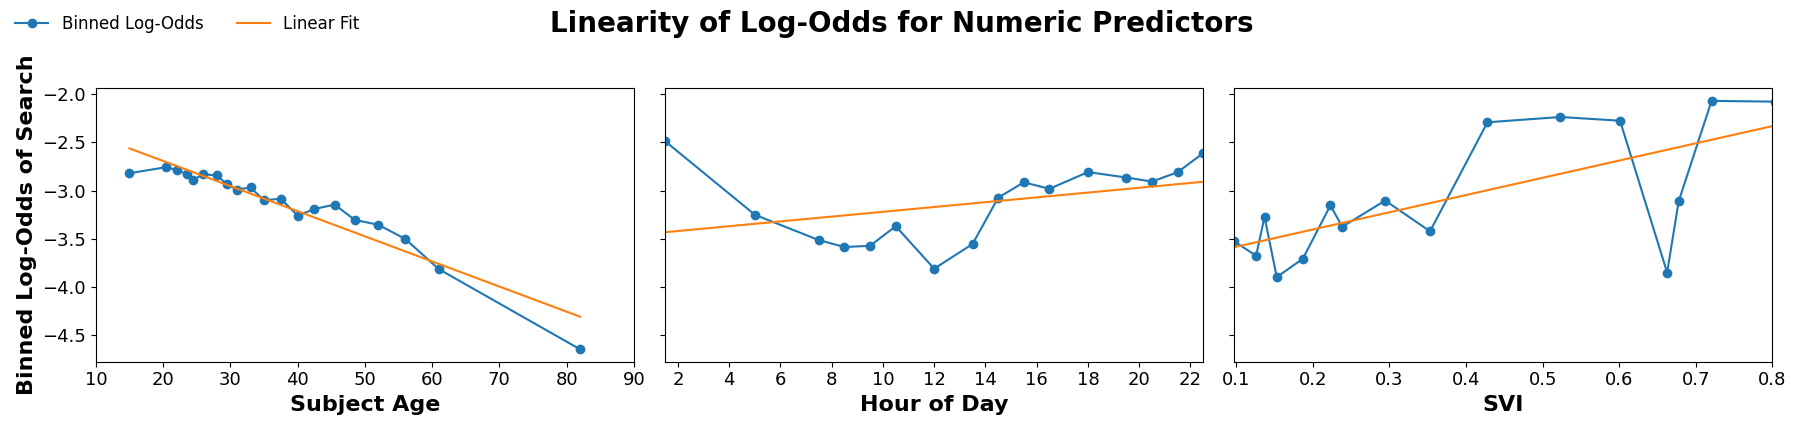

In [7]:
def binned_logit_plot_table(df, y_col, x_col, n_bins=20):
    tmp = df[[y_col, x_col]].copy()
    tmp["bin"] = pd.qcut(tmp[x_col], n_bins, duplicates="drop")
    g = tmp.groupby("bin")[y_col].agg(["mean", "size"]).reset_index()

    # If you've verified no bin has mean 0 or 1, this is safe:
    g["logit"] = np.log(g["mean"] / (1 - g["mean"]))
    g["x_mid"] = g["bin"].apply(lambda b: b.mid)

    return g[["x_mid", "mean", "logit", "size"]].sort_values("x_mid")

pretty = {"subject_age": "Subject Age", "hour": "Hour of Day", "svi": "SVI"}
x_vars = ["subject_age", "hour", "svi"]

TITLE_FONTSIZE = 20
SUBTITLE_FONTSIZE = 16
AXIS_LABEL_FONTSIZE = 16
TICK_FONTSIZE = 13
LEGEND_FONTSIZE = 12

fig, axes = plt.subplots(1, len(x_vars), figsize=(6 * len(x_vars), 4), sharey=True)
if len(x_vars) == 1:
    axes = [axes]

for ax, x in zip(axes, x_vars):
    tbl = binned_logit_plot_table(df, "search_conducted", x, n_bins=20)

    ax.plot(tbl["x_mid"], tbl["logit"], marker="o", label="Binned Log-Odds")
    slope, intercept = np.polyfit(tbl["x_mid"], tbl["logit"], 1)
    xline = np.linspace(tbl["x_mid"].min(), tbl["x_mid"].max(), 200)
    ax.plot(xline, intercept + slope * xline, label="Linear Fit")

    # Bold subplot title + axis labels
    # ax.set_title(
    #     pretty.get(x, x.replace("_", " ").title()),
    #     fontweight="bold",
    #     fontsize=SUBTITLE_FONTSIZE
    # )
    ax.set_xlabel(
        pretty.get(x, x.replace("_", " ").title()),
        fontweight="bold",
        fontsize=AXIS_LABEL_FONTSIZE
    )
    ax.set_xlim(tbl["x_mid"].min(), tbl["x_mid"].max())

    # Explicit tick rules
    if x == "hour":
        ax.set_xticks(np.arange(0, 24, 2))
        ax.set_xlim(max(tbl["x_mid"].min(), -0.5), min(tbl["x_mid"].max(), 23.5))

    elif x == "subject_age":
        lo = int(np.floor(tbl["x_mid"].min() / 10) * 10)
        hi = int(np.ceil(tbl["x_mid"].max() / 10) * 10)
        ax.set_xticks(np.arange(lo, hi + 1, 10))

    elif x == "svi":
        ax.set_xticks(np.arange(0.0, 0.81, 0.1))
        ax.set_xlim(max(tbl["x_mid"].min(), 0.0), min(tbl["x_mid"].max(), 0.8))
        #ax.legend(fontsize=LEGEND_FONTSIZE)

    # Larger tick labels
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)

    # Legend text size
    #ax.legend(fontsize=LEGEND_FONTSIZE)

# Bold y-axis label
axes[0].set_ylabel(
    "Binned Log-Odds of Search",
    fontweight="bold",
    fontsize=AXIS_LABEL_FONTSIZE
)

# Bold figure title
fig.suptitle(
    "Linearity of Log-Odds for Numeric Predictors",
    fontsize=TITLE_FONTSIZE,
    fontweight="bold",
    y=1.05
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", ncol=2, fontsize=LEGEND_FONTSIZE, frameon=False)

plt.tight_layout()
plt.show()

We can address the nonlinearity in the `hour` and `svi` variables in various ways. It may be the case that hourly data is too granular to make interpretations. As a result, we propose binning the hour into various interpretable categories, and treating it as a categorical variable for the logistic regression models. We define the following bins
* 12 AM - 6 AM: Late night and early morning hours. This is when most bars close and drunk drivers are on the road. This is also when people are typically most tired.
* 7 AM - 9 AM: This is when most people start waking up and heading to work. Similar people are on the road at these hours.
* 10 AM - 2 PM: This is when roads tend to be more empty. Those who are out may be leaving for lunch breaks.
* 3 PM - 5 PM: This is when many parents are picking their kids up from school. School zones are active and policing patterns may be different in these areas at this time.
* 6PM - 11 PM: This is when people are coming home from their daily activities, including work. Traffic is typically busiest around this time.

For the `svi` log-odds nonlinearity, we are unsure if this is due to discreteness. The amount of unique values is exactly equal to the number of policing zones. We will begin by fitting a linear term for the predictor. 

#### Fit

In [8]:
import os, random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (
    average_precision_score, roc_auc_score, accuracy_score,
    precision_score, recall_score, confusion_matrix
)

# Reproducibility
SEED = 832
random.seed(SEED)
np.random.seed(SEED)

# Bin the hours column
bins = [-0.5, 6.5, 9.5, 14.5, 17.5, 23.5]
labels = ["12AM-6AM", "7AM-9AM", "10AM-2PM", "3PM-5PM", "6PM-11PM"]
df["hour_bin"] = pd.cut(df["hour"], bins=bins, labels=labels)
df["hour_bin"] = pd.Categorical(df["hour_bin"], categories=labels, ordered=True)

# Set baselines
race_order = ["white", "hispanic", "black", "asian/pacific islander", "other"]
sex_order = [0, 1]  # if subject_sex is coded 0/1
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
hour_order = ["10AM-2PM", "12AM-6AM", "7AM-9AM", "3PM-5PM", "6PM-11PM"]  # baseline first
reason_order = ["Moving Violation", "Equipment Violation", "Radio Call/Citizen Contact",
                "Muni, County, H&S Code", "Personal Knowledge/Informant",
                "Suspect Info (I.S., Bulletin, Log)", "Other"]

ohe = OneHotEncoder(
    categories=[race_order, sex_order, reason_order, dow_order, hour_order],
    drop="first",
    handle_unknown="ignore"
)

# Define features and outcome
num_features = ["svi", "subject_age"]
cat_features = ["subject_race", "subject_sex", "reason_for_stop",
                "day_of_week", "hour_bin"]#, "service_area"]
X = df[num_features + cat_features].copy()
y = df["search_conducted"].copy()

# Data splitting (train = 70%, val = 15%, test = 15%)
X_train, X_, y_train, y_ = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_, y_, test_size=0.50, stratify=y_, random_state=SEED
)

# Scale numeric features and one-hot encode categoricals
# since LogisticRegression uses L2 regularization by default
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", ohe, cat_features),
    ]
)

# Baseline logistic regression model
baseline_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, solver="lbfgs", random_state=SEED))
])
baseline_model.fit(X_train, y_train)

# Prine baseline metrics on validation set
val_probs = baseline_model.predict_proba(X_val)[:, 1]
print("Baseline metrics on validation set:")
print("PR-AUC:", average_precision_score(y_val, val_probs))
print("ROC-AUC:", roc_auc_score(y_val, val_probs))
print("Baseline PR-AUC (prevalence):", y_val.mean())

# Stratified 5-fold Cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
tuned_lr = LogisticRegressionCV(
    Cs=[1e-3, 1e-2, 1e-1, 1, 10],
    cv=cv,
    scoring="average_precision", # loss is PR-AUC
    l1_ratios=(0,),
    solver="lbfgs",
    max_iter=2000,
    n_jobs=1,
    random_state=SEED,
    use_legacy_attributes=True
)

tuned_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", tuned_lr)
])

tuned_model.fit(X_train, y_train)

# Print tuned model metrics
val_probs_tuned = tuned_model.predict_proba(X_val)[:, 1]
print("\nTuned metrics on validation set (prior to threshold tuning):")
print("PR-AUC:", average_precision_score(y_val, val_probs_tuned))
print("ROC-AUC:", roc_auc_score(y_val, val_probs_tuned))
print("Chosen C:", tuned_model.named_steps["model"].C_[0])

# Tune the decision threshold on the validation set
thresholds = np.linspace(0.01, 0.50, 100)
best_thr, best_f1 = None, -1

for thr in thresholds:
    pred = (val_probs_tuned >= thr).astype(int)
    prec = precision_score(y_val, pred, zero_division=0)
    rec = recall_score(y_val, pred, zero_division=0)
    f1 = 0 if (prec + rec) == 0 else 2 * prec * rec / (prec + rec)
    if f1 > best_f1:
        best_f1, best_thr = f1, thr

print("\nChosen threshold (max F1 on val):", round(best_thr, 4), "F1:", round(best_f1, 4))

# Predict on the test set
test_probs = tuned_model.predict_proba(X_test)[:, 1]
test_pred = (test_probs >= best_thr).astype(int)

print("\nFINAL (test)")
print("PR-AUC:", average_precision_score(y_test, test_probs))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print("Accuracy:", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, zero_division=0))
print("Recall:", recall_score(y_test, test_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, test_pred))

# Look at "important" coefficients
# Get feature names after preprocessing
ohe = tuned_model.named_steps["preprocess"].named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(cat_features)
feature_names = np.concatenate([np.array(num_features), cat_names])

coefs = tuned_model.named_steps["model"].coef_.ravel()
coef_table = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "odds_ratio": np.exp(coefs),
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

print("\nTop 10 coefficients by |coef|:")
print(coef_table.head(10)[["feature","coef","odds_ratio"]])

Baseline metrics on validation set:
PR-AUC: 0.13034196177061103
ROC-AUC: 0.7489314610389982
Baseline PR-AUC (prevalence): 0.044235451554746015

Tuned metrics on validation set (prior to threshold tuning):
PR-AUC: 0.13107601293779572
ROC-AUC: 0.7490345849558538
Chosen C: 1.0

Chosen threshold (max F1 on val): 0.104 F1: 0.1971

FINAL (test)
PR-AUC: 0.13697518315174698
ROC-AUC: 0.7531197135823837
Accuracy: 0.8944130547914653
Precision: 0.1546348608495501
Recall: 0.3105042016806723
Confusion matrix:
 [[47384  4040]
 [ 1641   739]]

Top 10 coefficients by |coef|:
                                              feature      coef  odds_ratio
10       reason_for_stop_Personal Knowledge/Informant  2.274251    9.720636
8          reason_for_stop_Radio Call/Citizen Contact  2.102002    8.182534
11  reason_for_stop_Suspect Info (I.S., Bulletin, ...  2.032970    7.636735
9              reason_for_stop_Muni, County, H&S Code  1.694511    5.443981
7                 reason_for_stop_Equipment Violation  

In [9]:
import numpy as np
import pandas as pd

def make_or_table(tuned_model):
    # Pull fitted preprocessors
    pre = tuned_model.named_steps["preprocess"]
    ohe = pre.named_transformers_["cat"]
    scaler = pre.named_transformers_["num"]

    # Feature names in the same order as coefficients
    cat_names = ohe.get_feature_names_out(cat_features)
    feature_names = np.concatenate([np.array(num_features), cat_names])

    # Coefficients
    coefs = tuned_model.named_steps["model"].coef_.ravel()
    coef_map = dict(zip(feature_names, coefs))

    # Numeric scaling info (so you can describe SVI OR correctly)
    num_means = dict(zip(num_features, scaler.mean_))
    num_scales = dict(zip(num_features, scaler.scale_))

    rows = []

    def add_row(feature_label, feature_key, baseline, note=""):
        beta = coef_map[feature_key]
        rows.append({
            "Feature": feature_label,
            "Baseline": baseline,
            "Coef (log-odds)": beta,
            "Odds Ratio": float(np.exp(beta)),
            "Interpretation": f"{np.exp(beta):.2f}× odds vs baseline" + (f" ({note})" if note else "")
        })

    # 1) Reason: Personal Knowledge/Informant (baseline is your dropped reason)
    add_row(
        "Reason for Stop: Personal Knowledge/Informant",
        "reason_for_stop_Personal Knowledge/Informant",
        "Moving Violation"
    )

    # 2) Sex: subject_sex_1 (baseline = 0)
    add_row(
        "Subject Sex: Male",
        "subject_sex_1",
        "Female"
    )

    # 3) Race: Black (baseline = white, assuming you set it that way)
    add_row(
        "Subject Race: Black",
        "subject_race_black",
        "White"
    )

    # 4) Hour bin: 12AM–6AM (baseline = 10AM–2PM)
    add_row(
        "Time of Stop: 12AM–6AM",
        "hour_bin_12AM-6AM",
        "10AM–2PM"
    )

    # 5) SVI (numeric, scaled): OR is per 1 SD increase
    beta_svi = coef_map["svi"]
    rows.append({
        "Feature": "SVI",
        "Baseline": "N/A",
        "Coef (log-odds)": beta_svi,
        "Odds Ratio": float(np.exp(beta_svi)),
        "Interpretation": f"{np.exp(beta_svi):.2f}× odds per +1 SD in SVI (SD={num_scales['svi']:.3f})"
    })

    out = pd.DataFrame(rows)

    # Format for slides: keep it tight
    out["Coef (log-odds)"] = out["Coef (log-odds)"].map(lambda x: f"{x:.3f}")
    out["Odds Ratio"] = out["Odds Ratio"].map(lambda x: f"{x:.2f}")

    return out[["Feature", "Baseline", "Odds Ratio", "Interpretation"]]

or_table = make_or_table(tuned_model)
or_table.iloc[:, :-1]

,Feature,Baseline,Odds Ratio
0,Reason for Stop: Personal Knowledge/Informant,Moving Violation,9.72
1,Subject Sex: Male,Female,2.05
2,Subject Race: Black,White,1.95
3,Time of Stop: 12AM–6AM,10AM–2PM,1.90
4,SVI,N/A,1.32


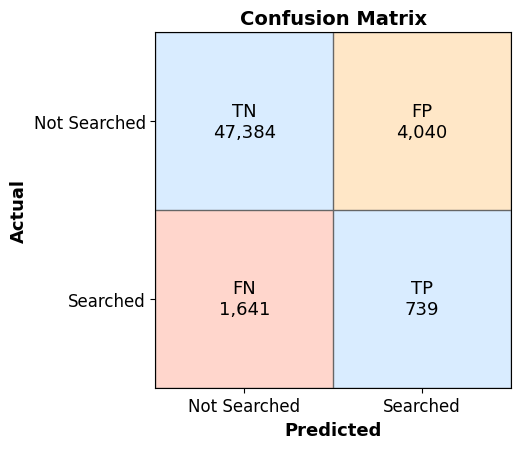

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_pred)  # [[TN, FP], [FN, TP]]

# Soft Okabe–Ito-inspired fills (pastel versions)
TN_COLOR = "#D9ECFF"  # soft blue
FP_COLOR = "#FFE7C7"  # soft orange
FN_COLOR = "#FFD6CC"  # soft vermillion/red
#TP_COLOR = "#DDF3E3"  # soft green
TP_COLOR = TN_COLOR

cell_colors = np.array([
    [0, 1],
    [2, 3]
])

cmap = ListedColormap([TN_COLOR, FP_COLOR, FN_COLOR, TP_COLOR])

fig, ax = plt.subplots(figsize=(5.8, 4.6))
ax.imshow(cell_colors, cmap=cmap, vmin=0, vmax=3)

# Labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Not Searched", "Searched"], fontsize=12)
ax.set_yticklabels(["Not Searched", "Searched"], fontsize=12)
ax.set_xlabel("Predicted", fontweight="bold", fontsize=13)
ax.set_ylabel("Actual", fontweight="bold", fontsize=13)
ax.set_title("Confusion Matrix", fontweight="bold", fontsize=14)

# Add gridlines between cells
ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
ax.grid(which="minor", color="#666666", linestyle="-", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

# Annotate counts + labels
labels = np.array([["TN", "FP"], ["FN", "TP"]])
for (i, j), val in np.ndenumerate(cm):
    ax.text(
        j, i,
        f"{labels[i,j]}\n{val:,}",
        ha="center", va="center",
        #fontweight="bold",
        fontsize=13
    )

plt.tight_layout()
plt.show()

We will break down the results into a few steps. To begin, observe that our scoring function for cross-validation is Precision-Recall Area Under the Curve (PR-AUC). This is because the outcome is rare, so ROC-AUC and accuracy can fail to capture Type I and Type II error rates. If we randomly ranked each stop, then the PR_AUC would be close to the prevalence of searches in the data set (roughly $4.4%$).

Our final ROC-AUC is moderately high, which is slightly misleading. The final model has a PR_AUC that is roughly three times the prevalence. Hence, the logistic regression model does not entirely seem to fail to learn about the data.

When tuning the threshold to maximize F1 score (chosen due to the rare outcome), we found that a much smaller threshold for positive prediction ($0.0842$, rather than $0.5$) worked best.

Finally, we will look at the largest coefficients in magnitude to gauge feature importance. The interpretation of each (categorical) coefficient $\beta_j$ is that subjects who happen to have $\beta_j$ as their $j$-th covariate are associated with a likelihood of search that is $e^{\beta_j}$ times higher odds of search than the baseline.

With this interpretation in mind, our logistic regression model appears to have identified a few things. Firstly, the most important factors in increasing the likelihood of a search are based on information tips to SDPD. This aligns with a well-functioning searching policy. Notably, being stopped for a moving violation appears to be associated with a decrease in the likelihood of being searched by approximately $53\%$

However, there also appear to be other factors which appear to be unrelated to information tips. For example, those who live in service area 710 appear to be associated with a approximately $63\%$ lower likelihood of being searched. The most prominent demographic factors that are associated with an increase in the likelihood of being searched include being black or hispanic, as well as being a male. Finally, being stopped between the hours of 12 AM to 6 PM, inclusive appear to be associated with an increase in the same likelihood.

In [11]:
ohe = tuned_model.named_steps["preprocess"].named_transformers_["cat"]
for feat, cats in zip(cat_features, ohe.categories_):
    print(feat, "baseline (dropped):", cats[0])

subject_race baseline (dropped): white
subject_sex baseline (dropped): 0
reason_for_stop baseline (dropped): Moving Violation
day_of_week baseline (dropped): Monday
hour_bin baseline (dropped): 10AM-2PM


### Mixed-Effects Logistic Regression

There are a few assumptions, many of which are similar to logistic regression. For example, we require that the outcome is binary and that outcomes are independent given the fixed (and, in this case, random) effects.

We include a random intercept for service area to model its effect. Indeed, we assume that, given the fixed effects, the differences of baseline search propensity in each policing zone can be captured by a random intercept, which we draw from a normal distribution with mean zero and variance $\sigma^2$. This may not be the case if, for example, some service areas are systemically over or underpoliced.

### XGBoost

We will use decision trees as the weak learner for this model. This is because there is a natural hierarchical interpretation to the model fit. This can help provide a benchmark for our more classical models. As with other models, we do still assume that the data are i.i.d. We also need to scale the features to avoid artificial dominant directions caused by natural differences in scales of the predictors.

Similarly, we also require that sample sizes are not small (which can destabilize the gradient descent), though this is not as much of a concern due to the large amount of data we have retained thus far.

Gradient boosting requires that the covariates are numeric. To ensure this, we will encode all categorical variables into dummies using one-hot encoding.